# Push-Wrench Episode Evaluation Analysis

This notebook analyzes episode-based quadruped locomotion evaluation CSVs collected under external push / wrench sweeps. It processes one file at a time to avoid keeping all raw logs in memory, computes the existing scalar metrics, collects per-episode success/failure results, and creates performance plots versus the L1 norm of the `--push_bounds` parameter.

For files named like `go1_pact_plane_push_2_1_2_episodes.csv`, the sweep value is:

```python
push_l1_norm = abs(2) + abs(1) + abs(2) = 5
```


In [19]:
import os, re, gc, ast
from pathlib import Path
from typing import Optional, Sequence, Tuple, List
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration


In [20]:
EXP_FOLDER = Path("exp_data_corl_10/wrench_max")
RESULTS_DIR = EXP_FOLDER / "push_wrench_analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Update these to match your filename prefixes.
# APPROACHES = ["go1_pact", "go1_pos"]
APPROACHES = ["go1_pact", "go1_pos", "go1_tau", "go1_abl1", "go1_abl2", "go1_abl3"]
# APPROACHES = ["go1_tau"]
TERRAINS = ["plane", "rough", "slope", "stairs", "discrete", "wave"]
TERRAIN_FILTER = ["plane"]          # e.g., ["plane"] or None
DISTURBANCE_PREFIX = "push"
PUSH_L1_ORDER = None           # e.g., [0, 2, 4, 6, 8, 10]
SUCCESS_THRESHOLD = 0.80
HIGHLIGHT_APPROACH = "PC"
RECOMPUTE_METRICS = False

APPROACH_ORDER = ['DW', 'TO', 'AB1', 'AB2', 'AB3', 'PC']
# APPROACH_ORDER = ['TO']

BASE_HEIGHT_TARGET = 0.30
EPS = 1e-8

JOINT_LIMITS = np.array([
    [-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
    [ 1.047,  2.966, -0.837,  1.047,  2.966, -0.837,  1.047,  2.966, -0.837,  1.047,  2.966, -0.837],
])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

ARRAY_COLUMNS = [
    "base_cmd", "base_pose", "base_rpy", "dof_pose", "base_lin_vel", "base_ang_vel",
    "dof_vel", "proj_grav", "feet_pos", "tau_act", "grf", "q_des", "tau_ff", "tau_pd",
    "payload", "com_shift", "rand_push", "rand_wrench",
]
USECOLS = None  # set to a list of columns to reduce memory even further

def _display_approach_name(approach):
    mapping = {"go1_pact": "PC", "go1_tau": "TO", "go1_pos": "DW", "go1_abl1": "AB1", "go1_abl2": "AB2", "go1_abl3": "AB3", "go1_rl2ac":"RA"}
    return mapping.get(approach, approach)

FIGURE_SIZE = (8.0, 2.6)
SAVE_AS_PDF = True

## Loading and filename parsing


In [21]:
def string_to_array(value):
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return value
    return value


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {c: string_to_array for c in columns}


def _decode_bound_token(token: str) -> Optional[float]:
    token = token.replace("neg", "-").replace("p", ".")
    try:
        return float(token)
    except Exception:
        return None


def parse_push_bounds_from_disturbance(disturbance_condition: str) -> List[float]:
    """Parse push bounds from tags like push_2_1_2_episodes.

    The evaluation script names push files using `_fmt_bounds("push", args.push_bounds)`,
    so the numeric tokens after `push` correspond to the command-line `--push_bounds` values.
    """
    if not isinstance(disturbance_condition, str) or "push" not in disturbance_condition:
        return []
    tokens = disturbance_condition.split("_")
    try:
        i = tokens.index("push")
    except ValueError:
        return []

    vals = []
    stop_tokens = {"episodes", "payload", "com", "none"}
    for tok in tokens[i + 1:]:
        if tok in stop_tokens:
            break
        val = _decode_bound_token(tok)
        if val is None:
            break
        vals.append(val)
    return vals


def parse_push_l1_from_disturbance(disturbance_condition: str) -> Optional[float]:
    """Return the L1 norm of the parsed `--push_bounds` vector."""
    vals = parse_push_bounds_from_disturbance(disturbance_condition)
    if not vals:
        return None
    return float(np.sum(np.abs(np.asarray(vals, dtype=float))))


def parse_eval_filename(path: Path, approaches: Sequence[str], terrains: Sequence[str]) -> Optional[dict]:
    stem = Path(path).stem
    for approach in sorted(approaches, key=len, reverse=True):
        prefix = f"{approach}_"
        if not stem.startswith(prefix):
            continue
        remainder = stem[len(prefix):]
        parts = remainder.split("_")
        if len(parts) < 2:
            continue
        terrain = parts[0]
        if terrain not in terrains:
            continue
        disturbance_condition = "_".join(parts[1:])
        return dict(
            approach=approach,
            terrain=terrain,
            disturbance_condition=disturbance_condition,
            push_bounds_from_name=parse_push_bounds_from_disturbance(disturbance_condition),
            push_l1_norm_from_name=parse_push_l1_from_disturbance(disturbance_condition),
            path=Path(path),
        )
    return None


def find_eval_files(exp_folder, approaches, terrains, terrain_filter=None, disturbance_prefix="push"):
    exp_folder = Path(exp_folder)
    terrain_filter = set(terrain_filter) if terrain_filter is not None else None
    records = []
    for path in sorted(exp_folder.rglob("*.csv")):
        if any(part.endswith("analysis_results") for part in path.parts):
            continue
        info = parse_eval_filename(path, approaches, terrains)
        if info is None:
            continue
        if terrain_filter is not None and info["terrain"] not in terrain_filter:
            continue
        if disturbance_prefix is not None and not info["disturbance_condition"].startswith(disturbance_prefix):
            continue
        records.append(info)
    out = pd.DataFrame(records)
    if len(out):
        out = out.sort_values(["approach", "terrain", "push_l1_norm_from_name", "path"], na_position="last")
    return out


def load_eval_csv(path: Path, usecols=USECOLS):
    converters = get_csv_converters()
    if usecols is not None:
        converters = {k: v for k, v in converters.items() if k in usecols}
    return pd.read_csv(path, converters=converters, usecols=usecols)


In [22]:
file_table = find_eval_files(
    EXP_FOLDER, APPROACHES, TERRAINS,
    terrain_filter=TERRAIN_FILTER,
    disturbance_prefix=DISTURBANCE_PREFIX,
)
print(f"Found {len(file_table)} files")
file_table


Found 150 files


,approach,terrain,disturbance_condition,push_bounds_from_name,push_l1_norm_from_name,path
0,go1_abl1,plane,push_0p5_0p1_0p5_episodes,"[0.5, 0.1, 0.5]",1.1000,exp_data_corl_10/wrench_max/go1_abl1_plane_pus...
1,go1_abl1,plane,push_0p6042_0p1792_0p6042_episodes,"[0.6042, 0.1792, 0.6042]",1.3876,exp_data_corl_10/wrench_max/go1_abl1_plane_pus...
2,go1_abl1,plane,push_0p7083_0p2583_0p7083_episodes,"[0.7083, 0.2583, 0.7083]",1.6749,exp_data_corl_10/wrench_max/go1_abl1_plane_pus...
3,go1_abl1,plane,push_0p8125_0p3375_0p8125_episodes,"[0.8125, 0.3375, 0.8125]",1.9625,exp_data_corl_10/wrench_max/go1_abl1_plane_pus...
4,go1_abl1,plane,push_0p9167_0p4167_0p9167_episodes,"[0.9167, 0.4167, 0.9167]",2.2501,exp_data_corl_10/wrench_max/go1_abl1_plane_pus...
...,...,...,...,...,...,...
145,go1_tau,plane,push_2p5833_1p6833_2p5833_episodes,"[2.5833, 1.6833, 2.5833]",6.8499,exp_data_corl_10/wrench_max/go1_tau_plane_push...
146,go1_tau,plane,push_2p6875_1p7625_2p6875_episodes,"[2.6875, 1.7625, 2.6875]",7.1375,exp_data_corl_10/wrench_max/go1_tau_plane_push...
147,go1_tau,plane,push_2p7917_1p8417_2p7917_episodes,"[2.7917, 1.8417, 2.7917]",7.4251,exp_data_corl_10/wrench_max/go1_tau_plane_push...
148,go1_tau,plane,push_2p8958_1p9208_2p8958_episodes,"[2.8958, 1.9208, 2.8958]",7.7124,exp_data_corl_10/wrench_max/go1_tau_plane_push...


## Existing metric utilities


In [23]:
def as_array(df, column, valid_mask=None):
    if column not in df.columns:
        return None
    s = df[column]
    if valid_mask is not None:
        s = s.loc[valid_mask]
    if len(s) == 0:
        return None
    try:
        return np.asarray(s.to_list())
    except Exception:
        return None


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))

def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))

def rmse(x):
    return float(np.sqrt(np.nanmean(np.square(np.asarray(x)))))

def mae(x):
    return float(np.nanmean(np.abs(np.asarray(x))))

def mean_norm(x, axis=1, ord=1):
    return float(np.nanmean(np.linalg.norm(np.asarray(x), axis=axis, ord=ord)))

def std_norm(x, axis=1, ord=1):
    return float(np.nanstd(np.linalg.norm(np.asarray(x), axis=axis, ord=ord)))


def get_row_mask_for_metrics(df):
    if "valid_episode" in df.columns:
        return df["valid_episode"].astype(float).to_numpy() == 1
    return np.ones(len(df), dtype=bool)


In [24]:
def compute_eval_metrics(
    df,
    approach="pact",
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """Compute scalar metrics from the original notebook; failure rows are excluded from continuous metrics."""
    metrics = {}
    use_pact_metrics = approach is not None and any(k.lower() in approach.lower() for k in pact_metric_approaches)

    n_total = len(df)
    if "failure_reset" in df.columns:
        failure = df["failure_reset"].astype(float).to_numpy()
    elif "failure" in df.columns:
        failure = df["failure"].astype(float).to_numpy()
    else:
        failure = np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate_rowwise"] = float(failure.mean()) if n_total else np.nan
    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)
    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)
    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)
    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)
    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    if q_actions is not None and q_obs is not None and q_actions.shape == q_obs.shape:
        e = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(e)
        metrics["dof_tracking_mae"] = mae(e)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)
        if joint_limits is not None:
            jl = np.asarray(joint_limits)
            err = -(q_actions - jl[0, :]).clip(max=0.0)
            err += (q_actions - jl[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(err))

    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_err = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_err = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_err = np.concatenate((lin_err, ang_err[:, None]), axis=1)
        metrics["lin_cmd_rmse"] = rmse(lin_err)
        metrics["lin_cmd_mae"] = mae(lin_err)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_err))))
        metrics["ang_cmd_rmse"] = rmse(ang_err)
        metrics["ang_cmd_mae"] = mae(ang_err)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_err))))
        metrics["total_cmd_rmse"] = rmse(cmd_err)
        metrics["total_cmd_mae"] = mae(cmd_err)

    if base_pose is not None:
        h = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(h)
        metrics["height_mae"] = mae(h)

    if proj_grav is not None:
        orn = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orn)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orn)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        av_rp = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        unwanted = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        unwanted_norm = np.linalg.norm(unwanted, axis=1, ord=1)
        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(av_rp)
        metrics["ang_vel_rp_norm_std"] = safe_std(av_rp)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(unwanted_norm)

    if q_vel is not None and q_tau is not None and q_vel.shape == q_tau.shape:
        power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(power)
        metrics["joint_power_norm_std"] = std_norm(power)

    if grfs is not None:
        flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(flat)
        metrics["grf_norm_std"] = std_norm(flat)
    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)
    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau)
        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))
        if joint_torque_limits is not None:
            lim = np.asarray(joint_torque_limits)
            violation = -(total_tau - (-lim)).clip(max=0.0)
            violation += (total_tau - lim).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel
        dot = np.sum(ff_power * pd_power, axis=1)
        ffn = np.linalg.norm(ff_power, axis=1)
        pdn = np.linalg.norm(pd_power, axis=1)
        cos = dot / ((ffn * pdn) + eps)
        metrics["ff_power_norm_mean"] = safe_mean(ffn)
        metrics["pd_power_norm_mean"] = safe_mean(pdn)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pdn) / (np.mean(ffn) + eps))
        metrics["power_alignment_mean"] = safe_mean(cos)
        metrics["power_alignment_std"] = safe_std(cos)
        metrics["fraction_antagonistic_energy"] = float(np.sum(np.maximum(-dot, 0.0)) / (np.sum(np.abs(dot)) + eps))
        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))
    return metrics


## Per-episode aggregation and memory-efficient processing


In [25]:
def _failure_series(df):
    if "failure_reset" in df.columns:
        return df["failure_reset"].astype(float)
    if "failure" in df.columns:
        return df["failure"].astype(float)
    return pd.Series(np.zeros(len(df)), index=df.index)


def _timeout_series(df):
    if "time_out" in df.columns:
        return df["time_out"].astype(float)
    return pd.Series(np.zeros(len(df)), index=df.index)


def compute_episode_results(df, approach, terrain, disturbance_condition, push_l1_norm, push_bounds, source_file):
    if "episode" not in df.columns:
        df = df.copy()
        df["episode"] = 0
    tmp = df.copy()
    tmp["_failure_event"] = _failure_series(tmp)
    tmp["_timeout_event"] = _timeout_series(tmp)

    q_des = as_array(tmp, "q_des")
    q = as_array(tmp, "dof_pose")
    if q_des is not None and q is not None and q_des.shape == q.shape:
        tmp["_dof_tracking_mae_row"] = np.mean(np.abs(q_des - q), axis=1)

    pose = as_array(tmp, "base_pose")
    if pose is not None and pose.ndim == 2 and pose.shape[1] >= 3:
        tmp["_height_abs_error_row"] = np.abs(BASE_HEIGHT_TARGET - pose[:, 2])

    agg = {"_failure_event": "max", "_timeout_event": "max"}
    if "episode_step" in tmp.columns:
        agg["episode_step"] = "max"
    if "_dof_tracking_mae_row" in tmp.columns:
        agg["_dof_tracking_mae_row"] = "mean"
    if "_height_abs_error_row" in tmp.columns:
        agg["_height_abs_error_row"] = "mean"

    ep = tmp.groupby("episode", as_index=False).agg(agg).rename(columns={
        "_failure_event": "failure",
        "_timeout_event": "time_out",
        "episode_step": "episode_length",
        "_dof_tracking_mae_row": "dof_tracking_mae",
        "_height_abs_error_row": "height_mae",
    })
    ep["success"] = 1.0 - ep["failure"].astype(float)
    ep["approach"] = approach
    ep["terrain"] = terrain
    ep["disturbance_condition"] = disturbance_condition
    ep["push_l1_norm"] = push_l1_norm
    ep["push_bounds"] = [push_bounds] * len(ep)
    ep["source_file"] = source_file
    cols = [
        "approach", "terrain", "push_l1_norm", "push_bounds", "disturbance_condition",
        "source_file", "episode", "success", "failure", "time_out", "episode_length",
        "dof_tracking_mae", "height_mae",
    ]
    return ep[[c for c in cols if c in ep.columns]]


def process_one_file(row):
    path = Path(row["path"])
    approach, terrain = row["approach"], row["terrain"]
    disturbance_condition = row["disturbance_condition"]

    df = load_eval_csv(path)
    df = df.loc[get_row_mask_for_metrics(df)].reset_index(drop=True)

    push_bounds = row.get("push_bounds_from_name", [])
    if not isinstance(push_bounds, list):
        push_bounds = [] if pd.isna(push_bounds) else list(push_bounds)

    push_l1_norm = row.get("push_l1_norm_from_name", np.nan)
    if push_l1_norm is None:
        push_l1_norm = np.nan

    metrics = compute_eval_metrics(
        df,
        approach=approach,
        base_height_target=BASE_HEIGHT_TARGET,
        joint_limits=JOINT_LIMITS,
        joint_torque_limits=JOINT_TORQUE_LIMITS,
        eps=EPS,
    )
    ep = compute_episode_results(df, approach, terrain, disturbance_condition, push_l1_norm, push_bounds, str(path))
    metrics.update({
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "push_l1_norm": push_l1_norm,
        "push_bounds": push_bounds,
        "source_file": str(path),
        "num_episodes": int(len(ep)),
        "episode_failure_rate": float(ep["failure"].mean()) if len(ep) else np.nan,
        "episode_success_rate": float(ep["success"].mean()) if len(ep) else np.nan,
    })
    del df
    gc.collect()
    return metrics, ep


def run_push_analysis(file_table, results_dir=RESULTS_DIR):
    file_metrics_path = results_dir / "per_file_metrics.csv"
    episode_results_path = results_dir / "per_episode_results.csv"
    if (not RECOMPUTE_METRICS) and file_metrics_path.exists() and episode_results_path.exists():
        return pd.read_csv(file_metrics_path), pd.read_csv(episode_results_path)

    metric_rows, episode_chunks = [], []
    for i, row in file_table.reset_index(drop=True).iterrows():
        print(f"[{i+1}/{len(file_table)}] {row['path']}")
        m, ep = process_one_file(row)
        metric_rows.append(m)
        episode_chunks.append(ep)
        pd.DataFrame(metric_rows).to_csv(file_metrics_path, index=False)
        pd.concat(episode_chunks, ignore_index=True).to_csv(episode_results_path, index=False)

    per_file = pd.DataFrame(metric_rows)
    per_ep = pd.concat(episode_chunks, ignore_index=True) if episode_chunks else pd.DataFrame()
    per_file.to_csv(file_metrics_path, index=False)
    per_ep.to_csv(episode_results_path, index=False)
    return per_file, per_ep

def _process_one_push_file_from_dict(row_dict):
    """
    Multiprocessing helper.

    Passing a plain dict is safer than passing a pandas Series because it is
    easier to pickle across processes.
    """
    row = pd.Series(row_dict)
    m, ep = process_one_file(row)
    return m, ep


def run_push_analysis_parallel(
    file_table,
    results_dir=RESULTS_DIR,
    max_workers=None,
    save_every=5,
):
    file_metrics_path = results_dir / "per_file_metrics.csv"
    episode_results_path = results_dir / "per_episode_results.csv"

    if (
        (not RECOMPUTE_METRICS)
        and file_metrics_path.exists()
        and episode_results_path.exists()
    ):
        return pd.read_csv(file_metrics_path), pd.read_csv(episode_results_path)

    results_dir.mkdir(parents=True, exist_ok=True)

    rows = file_table.reset_index(drop=True).to_dict(orient="records")
    total = len(rows)

    if total == 0:
        per_file = pd.DataFrame()
        per_ep = pd.DataFrame()
        per_file.to_csv(file_metrics_path, index=False)
        per_ep.to_csv(episode_results_path, index=False)
        return per_file, per_ep

    if max_workers is None:
        max_workers = max(1, min(os.cpu_count() or 1, total))

    metric_rows = []
    episode_chunks = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_process_one_push_file_from_dict, row): row
            for row in rows
        }

        for completed, future in enumerate(as_completed(futures), start=1):
            row = futures[future]
            path = row.get("path", "<unknown path>")

            try:
                m, ep = future.result()
            except Exception as e:
                print(f"[{completed}/{total}] FAILED: {path}")
                print(f"    {type(e).__name__}: {e}")
                continue

            print(f"[{completed}/{total}] finished: {path}")

            metric_rows.append(m)

            if ep is not None and len(ep) > 0:
                episode_chunks.append(ep)

            if completed % save_every == 0:
                pd.DataFrame(metric_rows).to_csv(file_metrics_path, index=False)

                if episode_chunks:
                    pd.concat(episode_chunks, ignore_index=True).to_csv(
                        episode_results_path,
                        index=False,
                    )

    per_file = pd.DataFrame(metric_rows)
    per_ep = (
        pd.concat(episode_chunks, ignore_index=True)
        if episode_chunks
        else pd.DataFrame()
    )

    per_file.to_csv(file_metrics_path, index=False)
    per_ep.to_csv(episode_results_path, index=False)

    return per_file, per_ep

In [26]:
# per_file_metrics, per_episode_results = run_push_analysis(file_table, RESULTS_DIR)
per_file_metrics, per_episode_results = run_push_analysis_parallel(
    file_table,
    max_workers=20,
    save_every=5,
)
print(f"Per-file rows: {len(per_file_metrics)}")
print(f"Per-episode rows: {len(per_episode_results)}")
per_file_metrics.head()


Per-file rows: 150
Per-episode rows: 15000


,num_rows_total,num_rows_valid,num_failures,failure_rate_rowwise,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,q_action_norm_std,joint_limit_violation_mean,lin_cmd_rmse,...,internal_power_cancellation,approach,terrain,disturbance_condition,push_l1_norm,push_bounds,source_file,num_episodes,episode_failure_rate,episode_success_rate
0,189257,189248,9,0.000048,0.143051,0.101743,9.375957,0.809034,0.000384,0.538070,...,0.433220,go1_abl1,plane,push_2p2708_1p4458_2p2708_episodes,5.9874,"[2.2708, 1.4458, 2.2708]",exp_data_corl_10/wrench_max/go1_abl1_plane_pus...,100,0.09,0.91
1,200075,200075,0,0.000000,0.113382,0.086008,9.298843,0.712632,0.000110,0.250558,...,0.498513,go1_abl1,plane,push_0p9167_0p4167_0p9167_episodes,2.2501,"[0.9167, 0.4167, 0.9167]",exp_data_corl_10/wrench_max/go1_abl1_plane_pus...,100,0.00,1.00
2,200075,200075,0,0.000000,0.111190,0.084547,9.297055,0.710173,0.000112,0.210069,...,0.507046,go1_abl1,plane,push_0p6042_0p1792_0p6042_episodes,1.3876,"[0.6042, 0.1792, 0.6042]",exp_data_corl_10/wrench_max/go1_abl1_plane_pus...,100,0.00,1.00
3,187385,187371,14,0.000075,0.145919,0.103208,9.390085,0.817971,0.000435,0.566079,...,0.428334,go1_abl1,plane,push_2p375_1p525_2p375_episodes,6.2750,"[2.375, 1.525, 2.375]",exp_data_corl_10/wrench_max/go1_abl1_plane_pus...,100,0.14,0.86
4,198733,198731,2,0.000010,0.118724,0.089217,9.317414,0.727390,0.000127,0.323260,...,0.486589,go1_abl1,plane,push_1p3333_0p7333_1p3333_episodes,3.3999,"[1.3333, 0.7333, 1.3333]",exp_data_corl_10/wrench_max/go1_abl1_plane_pus...,100,0.02,0.98


## Push-bound summary tables


In [27]:
def summarize_push_results(per_episode_results, per_file_metrics):
    ep = per_episode_results.copy()
    agg = dict(
        num_episodes=("episode", "count"),
        success_rate=("success", "mean"),
        failure_rate=("failure", "mean"),
        timeout_rate=("time_out", "mean"),
    )
    if "episode_length" in ep.columns:
        agg["episode_length_mean"] = ("episode_length", "mean")
    if "dof_tracking_mae" in ep.columns:
        agg["dof_tracking_mae"] = ("dof_tracking_mae", "mean")
    if "height_mae" in ep.columns:
        agg["height_mae"] = ("height_mae", "mean")

    summary = ep.groupby(["approach", "terrain", "push_l1_norm"], as_index=False).agg(**agg)

    metric_cols = [
        "lin_cmd_mae", "ang_cmd_mae", "total_cmd_mae", "total_cmd_rmse",
        "projected_gravity_rp_norm_mean", "z_vel_mae", "ang_vel_rp_norm_mean",
        "joint_power_norm_mean", "grf_norm_mean", "ff_tau_norm_mean", "pd_tau_norm_mean",
        "ff_tau_ratio_mean", "pd_to_ff_power_ratio", "power_alignment_mean",
        "fraction_antagonistic_energy", "internal_power_cancellation", "total_unwanted_vel_norm_mean"
    ]
    metric_cols = [c for c in metric_cols if c in per_file_metrics.columns]
    if metric_cols:
        file_summary = per_file_metrics.groupby(["approach", "terrain", "push_l1_norm"], as_index=False)[metric_cols].mean()
        summary = summary.merge(file_summary, on=["approach", "terrain", "push_l1_norm"], how="left")
    return summary.sort_values(["approach", "terrain", "push_l1_norm"])

push_summary = summarize_push_results(per_episode_results, per_file_metrics)
push_summary.to_csv(RESULTS_DIR / "push_summary.csv", index=False)
push_summary.head(20)


,approach,terrain,push_l1_norm,num_episodes,success_rate,failure_rate,timeout_rate,episode_length_mean,dof_tracking_mae,height_mae,...,joint_power_norm_mean,grf_norm_mean,ff_tau_norm_mean,pd_tau_norm_mean,ff_tau_ratio_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,total_unwanted_vel_norm_mean
0,go1_abl1,plane,1.1000,100,1.00,0.00,1.00,2000.75,0.084140,0.051852,...,37.122060,156.632513,57.248474,32.889497,0.647684,0.549142,-0.690915,0.882455,0.509282,0.595571
1,go1_abl1,plane,1.3876,100,1.00,0.00,1.00,2000.75,0.084547,0.051652,...,37.545957,157.397642,57.285544,33.019319,0.646813,0.549514,-0.686431,0.881169,0.507046,0.611853
2,go1_abl1,plane,1.6749,100,1.00,0.00,1.00,2000.75,0.084918,0.051467,...,38.093871,158.499129,57.269261,33.138983,0.645971,0.550176,-0.679878,0.878829,0.504673,0.627438
3,go1_abl1,plane,1.9625,100,1.00,0.00,1.00,2000.75,0.085483,0.051223,...,38.574328,159.435087,57.287251,33.308105,0.644705,0.550803,-0.672201,0.874808,0.501799,0.642890
4,go1_abl1,plane,2.2501,100,1.00,0.00,1.00,2000.75,0.086008,0.051019,...,39.371942,160.557421,57.371663,33.483013,0.643811,0.551282,-0.667344,0.869697,0.498513,0.662694
5,go1_abl1,plane,2.5374,100,1.00,0.00,1.00,2000.75,0.086637,0.050852,...,40.163854,161.569258,57.381056,33.687310,0.642587,0.552099,-0.658673,0.863128,0.494815,0.678807
6,go1_abl1,plane,2.8250,100,1.00,0.00,1.00,2000.75,0.087571,0.050578,...,41.247812,162.648751,57.425237,33.970649,0.640729,0.555142,-0.649063,0.851055,0.490069,0.700954
7,go1_abl1,plane,3.1126,100,0.99,0.01,0.99,1991.39,0.088301,0.050486,...,40.609821,163.836766,57.087435,33.994095,0.639780,0.556979,-0.642241,0.840244,0.487402,0.716342
8,go1_abl1,plane,3.3999,100,0.98,0.02,0.98,1987.33,0.089259,0.050279,...,41.761431,164.859067,57.399507,34.420550,0.637714,0.563517,-0.635612,0.841911,0.486589,0.735782
9,go1_abl1,plane,3.6875,100,0.98,0.02,0.98,1985.22,0.090657,0.050320,...,43.425764,165.625920,57.635291,34.837899,0.635698,0.562111,-0.624807,0.823180,0.479469,0.758859


In [28]:
def summarize_push_results_by_approach(payload_summary):
    metric_cols = [
        c for c in payload_summary.columns
        if c not in ["approach", "terrain", "push_l1_norm"]
    ]

    approach_summary = (
        payload_summary
        .groupby("approach", as_index=False)[metric_cols]
        .mean()
        .sort_values("approach", ignore_index=True)
    )

    return approach_summary


push_approach_summary = summarize_push_results_by_approach(push_summary)
# payload_approach_summary.to_csv(
#     RESULTS_DIR / "payload_approach_summary.csv",
#     index=False,
# )

push_approach_summary

,approach,num_episodes,success_rate,failure_rate,timeout_rate,episode_length_mean,dof_tracking_mae,height_mae,lin_cmd_mae,ang_cmd_mae,...,joint_power_norm_mean,grf_norm_mean,ff_tau_norm_mean,pd_tau_norm_mean,ff_tau_ratio_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,total_unwanted_vel_norm_mean
0,go1_abl1,100.0,0.8848,0.1152,0.8848,1882.7020,0.096728,0.049917,0.250648,0.173371,...,54.275965,168.716379,57.760720,36.346493,0.628161,0.602154,-0.588689,0.717422,0.456542,0.878804
1,go1_abl2,100.0,0.8496,0.1504,0.8496,1843.1020,0.105485,0.041358,0.239659,0.173943,...,53.300713,173.614736,29.652835,28.387762,0.532672,1.347896,0.790779,0.001106,0.033299,0.866569
2,go1_abl3,100.0,0.8720,0.1280,0.8720,1864.4284,0.110889,0.034273,0.245504,0.187072,...,49.190311,171.814335,25.634960,31.034463,0.468620,1.551026,0.811118,0.001099,0.030624,0.861506
3,go1_pact,100.0,0.9536,0.0464,0.9536,1956.6244,0.102982,0.042102,0.243492,0.170404,...,52.232587,169.728162,27.746419,27.612450,0.522087,1.251716,0.774939,0.003439,0.040821,0.816599
4,go1_pos,100.0,0.7616,0.2384,0.7616,1743.6276,0.178125,0.046342,0.249723,0.201030,...,54.379604,169.016118,0.000000,53.390086,NaN,NaN,NaN,NaN,NaN,0.923263
5,go1_tau,100.0,0.6580,0.3420,0.6580,1637.6780,0.302149,0.013972,0.259711,0.171566,...,60.756003,173.199269,49.778237,0.000000,NaN,NaN,NaN,NaN,NaN,0.899087


In [29]:
compact_cols = [
    "approach", "terrain", "payload_mass", "num_episodes", "success_rate", "failure_rate",
    "dof_tracking_mae", "height_mae", "total_cmd_mae", "projected_gravity_rp_norm_mean", "ang_vel_rp_norm_mean", "z_vel_mae",
    "total_unwanted_vel_norm_mean", "power_alignment_mean", "joint_power_norm_mean", "internal_power_cancellation",
]
compact_cols = [c for c in compact_cols if c in push_approach_summary.columns]
push_approach_summary[compact_cols].round(4)


,approach,num_episodes,success_rate,failure_rate,dof_tracking_mae,height_mae,total_cmd_mae,projected_gravity_rp_norm_mean,ang_vel_rp_norm_mean,z_vel_mae,total_unwanted_vel_norm_mean,power_alignment_mean,joint_power_norm_mean,internal_power_cancellation
0,go1_abl1,100.0,0.8848,0.1152,0.0967,0.0499,0.2249,0.0835,0.7803,0.0985,0.8788,-0.5887,54.2760,0.4565
1,go1_abl2,100.0,0.8496,0.1504,0.1055,0.0414,0.2178,0.0851,0.7765,0.0901,0.8666,0.7908,53.3007,0.0333
2,go1_abl3,100.0,0.8720,0.1280,0.1109,0.0343,0.2260,0.1086,0.7637,0.0978,0.8615,0.8111,49.1903,0.0306
3,go1_pact,100.0,0.9536,0.0464,0.1030,0.0421,0.2191,0.0793,0.7274,0.0892,0.8166,0.7749,52.2326,0.0408
4,go1_pos,100.0,0.7616,0.2384,0.1781,0.0463,0.2335,0.0854,0.8189,0.1044,0.9233,NaN,54.3796,NaN
5,go1_tau,100.0,0.6580,0.3420,0.3021,0.0140,0.2303,0.1030,0.7833,0.1158,0.8991,NaN,60.7560,NaN


In [30]:
compact_cols = [
    "approach", "terrain", "push_l1_norm", "num_episodes", "success_rate", "failure_rate",
    "dof_tracking_mae", "height_mae", "total_cmd_mae", "projected_gravity_rp_norm_mean",
    "joint_power_norm_mean", "internal_power_cancellation",
]
compact_cols = [c for c in compact_cols if c in push_summary.columns]
push_summary[compact_cols].round(4)


,approach,terrain,push_l1_norm,num_episodes,success_rate,failure_rate,dof_tracking_mae,height_mae,total_cmd_mae,projected_gravity_rp_norm_mean,joint_power_norm_mean,internal_power_cancellation
0,go1_abl1,plane,1.1000,100,1.00,0.00,0.0841,0.0519,0.1232,0.0582,37.1221,0.5093
1,go1_abl1,plane,1.3876,100,1.00,0.00,0.0845,0.0517,0.1287,0.0595,37.5460,0.5070
2,go1_abl1,plane,1.6749,100,1.00,0.00,0.0849,0.0515,0.1344,0.0608,38.0939,0.5047
3,go1_abl1,plane,1.9625,100,1.00,0.00,0.0855,0.0512,0.1406,0.0623,38.5743,0.5018
4,go1_abl1,plane,2.2501,100,1.00,0.00,0.0860,0.0510,0.1466,0.0638,39.3719,0.4985
...,...,...,...,...,...,...,...,...,...,...,...,...
145,go1_tau,plane,6.8499,100,0.16,0.84,0.3098,0.0169,0.2980,0.1247,75.0318,NaN
146,go1_tau,plane,7.1375,100,0.19,0.81,0.3093,0.0180,0.3218,0.1300,78.7580,NaN
147,go1_tau,plane,7.4251,100,0.07,0.93,0.3135,0.0180,0.3298,0.1324,83.7690,NaN
148,go1_tau,plane,7.7124,100,0.11,0.89,0.3172,0.0191,0.3521,0.1427,90.8134,NaN


## Plotting helpers


In [51]:
def prepare_plot_summary(summary, terrain=None):
    out = summary.copy()
    out["approach_label"] = out["approach"].map(_display_approach_name)
    if terrain is not None:
        out = out[out["terrain"] == terrain]
    return out.sort_values(["approach_label", "push_l1_norm"])


def push_curve_dict(summary, value_col, terrain=None):
    plot_df = prepare_plot_summary(summary, terrain=terrain)
    push_l1_values = PUSH_L1_ORDER
    if push_l1_values is None:
        push_l1_values = sorted(plot_df["push_l1_norm"].dropna().unique())
    push_l1_values = np.asarray(push_l1_values, dtype=float)
    curves = {}
    for approach, group in plot_df.groupby("approach_label"):
        s = group.groupby("push_l1_norm")[value_col].mean()
        curves[approach] = np.asarray([s.get(p, np.nan) for p in push_l1_values], dtype=float)
    return push_l1_values, curves

def save_paper_fig(fig, path, pad_inches=0.00):
    fig.savefig(
        path,
        bbox_inches="tight",
        pad_inches=pad_inches,
        dpi=300,
    )

def compactify_plot(
    fig,
    ax=None,
    pad=0.00,
    tick_pad=0,
    label_pad=0,
    title_pad=0,
):
    """
    Reduce whitespace around a matplotlib figure for paper-ready plots.
    """
    axes = fig.axes if ax is None else [ax]

    for a in axes:
        a.tick_params(axis="both", which="major", pad=tick_pad)
        a.xaxis.labelpad = label_pad
        a.yaxis.labelpad = label_pad

    fig.tight_layout(pad=pad)
    return fig

def plot_push_success_curves(push_l1_values, success_rates, approach_order=None, highlight="PACT", ax=None, shade_until=None, shade_label=None, shade_alpha=0.18):
    if ax is None:
        fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    else:
        fig = ax.figure
    if approach_order is None:
        approach_order = list(success_rates.keys())
    markers = ["o", "s", "^", "D", "P", "v", "X", "*"]
    
    # Grey out background from the left edge up to shade_until.
    if shade_until is not None:
        x_min = np.nanmin(push_l1_values)
        ax.axvspan(
            x_min,
            shade_until,
            color="gray",
            alpha=shade_alpha,
            zorder=0,
            label=shade_label,
        )

    for i, approach in enumerate(approach_order):
        y = np.asarray(success_rates[approach])
        is_highlight = approach == highlight
        ax.plot(push_l1_values, 100.0*y, marker=markers[i % len(markers)], linewidth=2.6 if is_highlight else 1.2,
                markersize=5.5 if is_highlight else 4.0, alpha=1.0 if is_highlight else 0.55,
                label=approach, zorder=10 if is_highlight else 2)
    ax.set_xlabel("Push Bound $\\|\\cdot\\|_1$", fontsize=16)
    # ax.set_ylabel("Success Rate (%)")
    ax.set_ylim(-3, 103)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", alpha=0.3)
    
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)

    # ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    # ax.legend(fontsize=8)
    ax.legend(
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        ncol=4,
        frameon=True,
        fontsize=12,
    )
    fig.tight_layout()
    return fig, ax


def plot_push_failure_curves(push_l1_values, failure_rates, approach_order=None, highlight="PACT", ax=None, shade_until=None, shade_label=None, shade_alpha=0.18):
    if ax is None:
        fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    else:
        fig = ax.figure
    if approach_order is None:
        approach_order = list(failure_rates.keys())
    markers = ["o", "s", "^", "D", "P", "v", "X", "*"]
    
    # Grey out background from the left edge up to shade_until.
    if shade_until is not None:
        x_min = np.nanmin(push_l1_values)
        ax.axvspan(
            x_min,
            shade_until,
            color="gray",
            alpha=shade_alpha,
            zorder=0,
            label=shade_label,
        )

    for i, approach in enumerate(approach_order):
        y = np.asarray(failure_rates[approach])
        is_highlight = approach == highlight
        ax.plot(push_l1_values, 100.0*y, marker=markers[i % len(markers)], linewidth=2.6 if is_highlight else 1.2,
                markersize=5.5 if is_highlight else 4.0, alpha=1.0 if is_highlight else 0.55,
                label=approach, zorder=10 if is_highlight else 2)
    ax.set_xlabel("Push Bound $\\|\\cdot\\|_1$")
    ax.set_ylabel("Failure Rate (%)")
    ax.set_ylim(-3, 103)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(True, axis="y", alpha=0.3)
    # ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
    )
    fig.tight_layout()
    return fig, ax


def compute_push_threshold(push_l1_values, success_rates, threshold=0.8):
    push_l1_values = np.asarray(push_l1_values)
    thresholds = {}
    for approach, rates in success_rates.items():
        rates = np.asarray(rates)
        valid = push_l1_values[rates >= threshold]
        thresholds[approach] = valid.max() if len(valid) > 0 else 0.0
    return thresholds


# def plot_push_thresholds(thresholds, threshold=0.8, highlight="PACT", approach_order=None):
#     if approach_order is None:
#         approaches = list(thresholds.keys())
#     else:
#         # Keep only approaches that exist in thresholds.
#         approaches = [a for a in approach_order if a in thresholds]

#         # Optionally append any approaches not specified in approach_order.
#         remaining = [a for a in thresholds.keys() if a not in approaches]
#         approaches.extend(remaining)

#     values = [thresholds[a] for a in approaches]

#     fig, ax = plt.subplots(figsize=FIGURE_SIZE)
#     bars = ax.bar(approaches, values)

#     for bar, approach in zip(bars, approaches):
#         if approach == highlight:
#             bar.set_linewidth(2.0)
#             bar.set_edgecolor("black")

#     ax.set_ylabel(f"Max Push Bound $\\|\\cdot\\|_1$ at\n≥{int(100 * threshold)}% Success")
#     ax.set_xlabel("Approach")
#     ax.tick_params(axis="x", rotation=30)
#     ax.grid(True, axis="y", alpha=0.3)

#     fig.tight_layout()
#     return fig, ax

def plot_push_thresholds(
    thresholds,
    threshold=0.8,
    highlight="PACT",
    approach_order=None,
    annotate=True,
):
    if approach_order is None:
        approaches = list(thresholds.keys())
    else:
        # Keep only approaches that exist in thresholds.
        approaches = [a for a in approach_order if a in thresholds]

        # Optionally append any approaches not specified in approach_order.
        remaining = [a for a in thresholds.keys() if a not in approaches]
        approaches.extend(remaining)

    values = np.asarray([thresholds[a] for a in approaches], dtype=float)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    bars = ax.bar(approaches, values)

    for bar, approach in zip(bars, approaches):
        if approach == highlight:
            bar.set_linewidth(2.0)
            bar.set_edgecolor("black")

    if annotate:
        ax.bar_label(
            bars,
            labels=[f"{v:.2f}" if np.isfinite(v) else "" for v in values],
            padding=2,
            fontsize=8,
        )

        # Add headroom so labels are not clipped.
        ymin, ymax = ax.get_ylim()
        y_range = ymax - ymin
        ax.set_ylim(ymin, ymax + 0.10 * y_range)

    ax.set_ylabel(f"Max Push Bound $\\|\\cdot\\|_1$ at\n≥{int(100 * threshold)}% Success")
    ax.set_xlabel("Approach")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    return fig, ax


def plot_metric_vs_push_l1(summary, metric, terrain=None, ylabel=None, highlight="PACT", approach_order=None, shade_until=None, shade_label=None, shade_alpha=0.18, exclude_approaches=None):
    push_l1_values, curves = push_curve_dict(summary, metric, terrain=terrain)

    if approach_order is None:
        order = list(curves.keys())
    else:
        # Keep requested order for approaches that exist in curves.
        order = [a for a in approach_order if a in curves]

        # Append any remaining approaches not explicitly listed.
        remaining = [a for a in curves.keys() if a not in order]
        order.extend(remaining)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    # Grey out background from the left edge up to shade_until.
    if shade_until is not None:
        x_min = np.nanmin(push_l1_values)
        ax.axvspan(
            x_min,
            shade_until,
            color="gray",
            alpha=shade_alpha,
            zorder=0,
            label=shade_label,
        )

    markers = ["o", "s", "^", "D", "P", "v", "X", "*"]
    for i, approach in enumerate(order):
        if exclude_approaches is not None:
            if approach in exclude_approaches:
                continue
        
        is_highlight = approach == highlight
        ax.plot(push_l1_values, curves[approach], marker=markers[i % len(markers)], linewidth=2.6 if is_highlight else 1.2,
                markersize=5.5 if is_highlight else 4.0, alpha=1.0 if is_highlight else 0.55,
                label=approach, zorder=10 if is_highlight else 2)
    ax.set_xlabel("Push Bound $\\|\\cdot\\|_1$")
    ax.set_ylabel(ylabel or metric)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    # ax.set_title(metric if terrain is None else f"{metric} ({terrain})")
    fig.tight_layout()
    return fig, ax


## Push failure/success plots


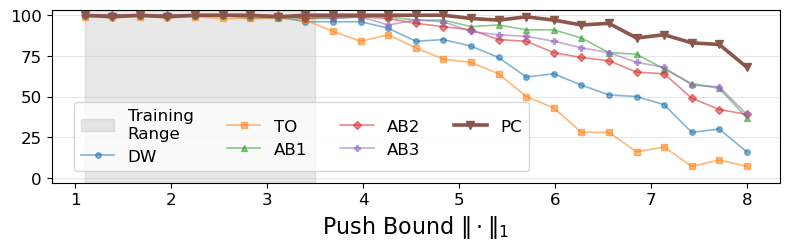

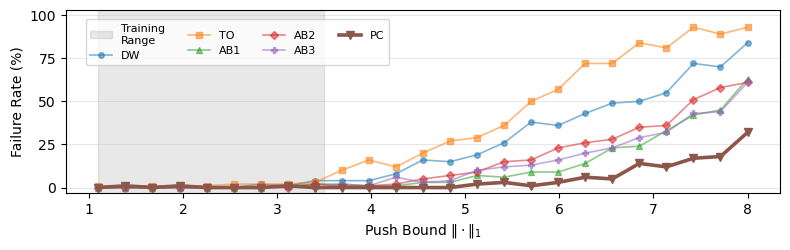

In [52]:
PLOT_TERRAIN = "plane" if "plane" in push_summary["terrain"].unique() else None

push_l1_values, success_rates = push_curve_dict(push_summary, "success_rate", terrain=PLOT_TERRAIN)
_, failure_rates = push_curve_dict(push_summary, "failure_rate", terrain=PLOT_TERRAIN)
approach_order =  list(success_rates.keys()) if APPROACH_ORDER is None else APPROACH_ORDER


fig, ax = plot_push_success_curves(push_l1_values, success_rates, approach_order, highlight=HIGHLIGHT_APPROACH, shade_until=3.5, shade_label="Training\nRange")
fig.savefig(RESULTS_DIR / "push_success_curves.png", dpi=300, bbox_inches="tight")
plt.show()

if SAVE_AS_PDF:
    compactify_plot(fig, ax)
    save_paper_fig(fig, RESULTS_DIR / "push_success_curves.pdf")

fig, ax = plot_push_failure_curves(push_l1_values, failure_rates, approach_order, highlight=HIGHLIGHT_APPROACH, shade_until=3.5, shade_label="Training\nRange")
fig.savefig(RESULTS_DIR / "push_failure_curves.png", dpi=300, bbox_inches="tight")
plt.show()

if SAVE_AS_PDF:
    compactify_plot(fig, ax)
    save_paper_fig(fig, RESULTS_DIR / "push_failure_curves.pdf")


## Maximum push-bound L1 norm before success threshold


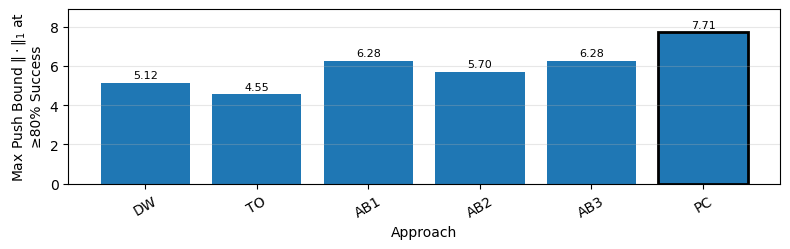

In [53]:
thresholds = compute_push_threshold(push_l1_values, success_rates, threshold=SUCCESS_THRESHOLD)
threshold_table = pd.DataFrame({
    "approach": list(thresholds.keys()),
    "max_push_l1_at_threshold": list(thresholds.values()),
    "success_threshold": SUCCESS_THRESHOLD,
})
threshold_table.to_csv(RESULTS_DIR / "push_success_thresholds.csv", index=False)
fig, ax = plot_push_thresholds(thresholds, threshold=SUCCESS_THRESHOLD, highlight=HIGHLIGHT_APPROACH, approach_order=approach_order)
fig.savefig(RESULTS_DIR / "push_success_thresholds.png", dpi=300, bbox_inches="tight")
plt.show()

if SAVE_AS_PDF:
    compactify_plot(fig, ax)
    save_paper_fig(fig, RESULTS_DIR / "push_success_thresholds.pdf")


## DoF and height tracking vs. push-bound L1 norm


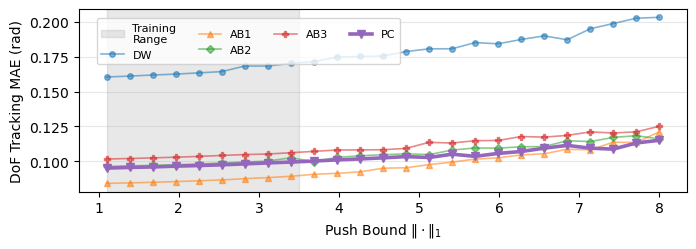

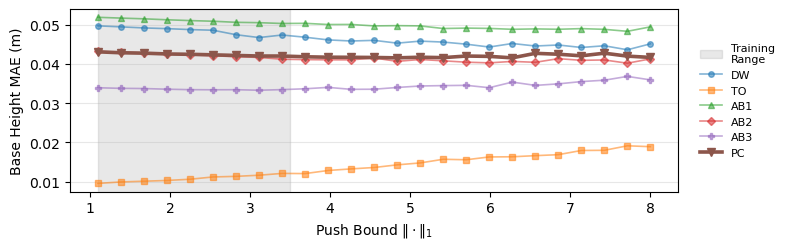

In [46]:
if "dof_tracking_mae" in push_summary.columns:
    fig, ax = plot_metric_vs_push_l1(push_summary, "dof_tracking_mae", terrain=PLOT_TERRAIN, ylabel="DoF Tracking MAE (rad)",
                                     highlight=HIGHLIGHT_APPROACH, approach_order=approach_order, shade_until=3.5, shade_label="Training\nRange",
                                     exclude_approaches=["TO"])
    
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
        )
    
    fig.savefig(RESULTS_DIR / "push_dof_tracking_mae.png", dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE_AS_PDF:
        compactify_plot(fig, ax)
        save_paper_fig(fig, RESULTS_DIR / "push_dof_tracking_mae.pdf")

else:
    print("dof_tracking_mae is not available.")

if "height_mae" in push_summary.columns:
    fig, ax = plot_metric_vs_push_l1(push_summary, "height_mae", terrain=PLOT_TERRAIN, ylabel="Base Height MAE (m)", highlight=HIGHLIGHT_APPROACH, approach_order=approach_order, shade_until=3.5, shade_label="Training\nRange")
    
    fig.savefig(RESULTS_DIR / "push_height_mae.png", dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE_AS_PDF:
        compactify_plot(fig, ax)
        save_paper_fig(fig, RESULTS_DIR / "push_height_mae.pdf")

else:
    print("height_mae is not available.")


## Optional: plot any metric from the existing analysis


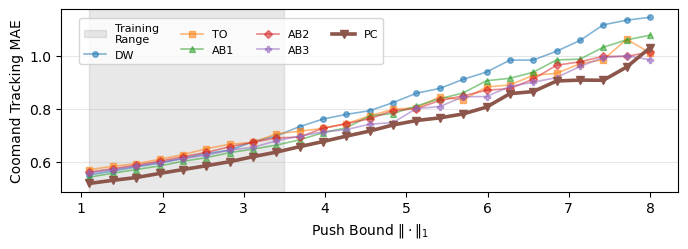

['approach', 'terrain', 'push_l1_norm', 'num_episodes', 'success_rate', 'failure_rate', 'timeout_rate', 'episode_length_mean', 'dof_tracking_mae', 'height_mae', 'lin_cmd_mae', 'ang_cmd_mae', 'total_cmd_mae', 'total_cmd_rmse', 'projected_gravity_rp_norm_mean', 'z_vel_mae', 'ang_vel_rp_norm_mean', 'joint_power_norm_mean', 'grf_norm_mean', 'ff_tau_norm_mean', 'pd_tau_norm_mean', 'ff_tau_ratio_mean', 'pd_to_ff_power_ratio', 'power_alignment_mean', 'fraction_antagonistic_energy', 'internal_power_cancellation', 'total_unwanted_vel_norm_mean']


In [35]:
METRIC_TO_PLOT = "ang_vel_rp_norm_mean"
if METRIC_TO_PLOT in push_summary.columns:
    fig, ax = plot_metric_vs_push_l1(push_summary, METRIC_TO_PLOT, terrain=PLOT_TERRAIN, ylabel="Coomand Tracking MAE", highlight=HIGHLIGHT_APPROACH, approach_order=approach_order, shade_until=3.5, shade_label="Training\nRange")
    
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=4,  # 7 entries -> 2 rows
        frameon=True,
        fontsize=8,
        )
    
    fig.savefig(RESULTS_DIR / f"push_{METRIC_TO_PLOT}.png", dpi=300, bbox_inches="tight")
    plt.show()

    if SAVE_AS_PDF:
        compactify_plot(fig, ax)
        save_paper_fig(fig, RESULTS_DIR / f"push_{METRIC_TO_PLOT}.pdf")

else:
    print(f"{METRIC_TO_PLOT!r} is not available.")
    print(push_summary.columns.tolist())
print(push_summary.columns.tolist())

## Export final tables


In [36]:
per_file_metrics.to_csv(RESULTS_DIR / "per_file_metrics.csv", index=False)
per_episode_results.to_csv(RESULTS_DIR / "per_episode_results.csv", index=False)
push_summary.to_csv(RESULTS_DIR / "push_summary.csv", index=False)
threshold_table.to_csv(RESULTS_DIR / "push_success_thresholds.csv", index=False)

print("Final outputs written to:")
for name in [
    "per_file_metrics.csv", "per_episode_results.csv", "push_summary.csv", "push_success_thresholds.csv",
    "push_success_curves.png", "push_failure_curves.png", "push_success_thresholds.png",
    "push_dof_tracking_mae.png", "push_height_mae.png",
]:
    print(RESULTS_DIR / name)


Final outputs written to:
exp_data_corl_10/wrench_max/push_wrench_analysis_results/per_file_metrics.csv
exp_data_corl_10/wrench_max/push_wrench_analysis_results/per_episode_results.csv
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_summary.csv
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_success_thresholds.csv
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_success_curves.png
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_failure_curves.png
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_success_thresholds.png
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_dof_tracking_mae.png
exp_data_corl_10/wrench_max/push_wrench_analysis_results/push_height_mae.png
